# Analyse des quotas régionaux d’accueil à partir des documents juridiques

Ce notebook vise à reconstituer et comparer les quotas de répartition des personnes déplacées d’Ukraine vers les différentes régions de la Fédération de Russie, tels qu’ils apparaissent dans plusieurs versions de documents juridiques russes.

Le notebook procède en trois temps : saisie structurée des données juridiques, vérification de cohérence des totaux, puis comparaison graphique de l’évolution des quotas entre les différentes révisions.


## 1. Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Version initiale du 12 mars 2022

Cette cellule encode la première répartition des quotas sous forme de dictionnaire Python. Les données sont organisées à trois niveaux : la date de la version juridique, le total officiel, puis la distribution par district fédéral et par région.

Cette structuration permet de conserver la hiérarchie administrative du document juridique tout en facilitant les calculs ultérieurs.


In [14]:
revision_2022_03_12 = {
    "date": "12 mars 2022 — version initiale",
    "total": 95909,
    "districts": {
        "District fédéral central": {
            "total": 27405,
            "regions": {
                "Белгородская область": 4547,
                "Брянская область": 1497,
                "Владимирская область": 1734,
                "Воронежская область": 7000,
                "Ивановская область": 350,
                "Калужская область": 620,
                "Костромская область": 440,
                "Курская область": 3000,
                "Липецкая область": 735,
                "Московская область": 1595,
                "Орловская область": 1000,
                "Рязанская область": 1208,
                "Смоленская область": 126,
                "Тамбовская область": 800,
                "Тверская область": 300,
                "Тульская область": 1653,
                "Ярославская область": 800,
                "Город Москва": 0
            }
        },

        "District fédéral du Nord-Ouest": {
            "total": 5949,
            "regions": {
                "Республика Карелия": 400,
                "Республика Коми": 530,
                "Архангельская область": 370,
                "Вологодская область": 310,
                "Калининградская область": 350,
                "Ленинградская область": 520,
                "Мурманская область": 2452,
                "Новгородская область": 87,
                "Псковская область": 700,
                "Город Санкт-Петербург": 0,
                "Ненецкий автономный округ": 230
            }
        },

        "District fédéral du Sud": {
            "total": 16293,
            "regions": {
                "Республика Крым": 4788,
                "Республика Адыгея": 200,
                "Республика Калмыкия": 200,
                "Краснодарский край": 5330,
                "Астраханская область": 600,
                "Волгоградская область": 450,
                "Ростовская область": 4725,
                "Город Севастополь": 0
            }
        },

        "District fédéral du Caucase du Nord": {
            "total": 7023,
            "regions": {
                "Республика Дагестан": 1268,
                "Республика Ингушетия": 300,
                "Кабардино-Балкарская Республика": 800,
                "Карачаево-Черкесская Республика": 150,
                "Республика Северная Осетия — Алания": 1000,
                "Чеченская Республика": 1500,
                "Ставропольский край": 2005
            }
        },

        "District fédéral de la Volga": {
            "total": 15666,
            "regions": {
                "Республика Башкортостан": 1867,
                "Республика Марий Эл": 280,
                "Республика Мордовия": 500,
                "Республика Татарстан": 1020,
                "Удмуртская Республика": 550,
                "Чувашская Республика": 1259,
                "Пермский край": 1510,
                "Кировская область": 536,
                "Нижегородская область": 2100,
                "Оренбургская область": 300,
                "Пензенская область": 2230,
                "Самарская область": 2076,
                "Саратовская область": 480,
                "Ульяновская область": 958
            }
        },

        "District fédéral de l’Oural": {
            "total": 4687,
            "regions": {
                "Курганская область": 100,
                "Свердловская область": 1650,
                "Тюменская область": 1600,
                "Челябинская область": 565,
                "Ханты-Мансийский автономный округ — Югра": 572,
                "Ямало-Ненецкий автономный округ": 200
            }
        },

        "District fédéral sibérien": {
            "total": 11568,
            "regions": {
                "Республика Алтай": 170,
                "Республика Тыва": 240,
                "Республика Хакасия": 424,
                "Алтайский край": 500,
                "Красноярский край": 3920,
                "Иркутская область": 460,
                "Кемеровская область — Кузбасс": 1530,
                "Новосибирская область": 1200,
                "Омская область": 2369,
                "Томская область": 755
            }
        },

        "District fédéral extrême-oriental": {
            "total": 7318,
            "regions": {
                "Республика Бурятия": 1402,
                "Республика Саха (Якутия)": 534,
                "Забайкальский край": 940,
                "Камчатский край": 200,
                "Приморский край": 1350,
                "Хабаровский край": 740,
                "Амурская область": 517,
                "Магаданская область": 200,
                "Сахалинская область": 1305,
                "Еврейская автономная область": 50,
                "Чукотский автономный округ": 80
            }
        },

        "Territoires ukrainiens occupés": {
            "total": 0,
            "regions": {}
        }
    }
}

### Vérification du total pour la version du 12 mars 2022

Cette cellule additionne les quotas indiqués pour les différents districts fédéraux et compare le résultat avec le total officiel mentionné dans le document. L’écart calculé permet de repérer d’éventuelles erreurs de saisie ou incohérences internes.


In [15]:
# Проверка total по редакции
total_2022_03_12 = sum(
    district_data["total"]
    for district_data in revision_2022_03_12["districts"].values()
)

print("Total calculé pour la révision du 12 mars 2022 :", total_2022_03_12)
print("Total officiel :", revision_2022_03_12["total"])
print("Écart :", total_2022_03_12 - revision_2022_03_12["total"])

Total calculé pour la révision du 12 mars 2022 : 95909
Total officiel : 95909
Écart : 0


## 3. Révision du 18 avril 2022

Cette cellule saisit la révision suivante du dispositif de répartition. La comparaison avec la version initiale permet d’observer les premiers ajustements administratifs des quotas quelques semaines après la mise en place du dispositif.


In [16]:
revision_2022_04_18 = {
    "date": "18 avril 2022",
    "total": 95146,
    "districts": {
        "District fédéral central": {
            "total": 28890,
            "regions": {
                "Белгородская область": 4547,
                "Брянская область": 1497,
                "Владимирская область": 1734,
                "Воронежская область": 7000,
                "Ивановская область": 350,
                "Калужская область": 1240,
                "Костромская область": 440,
                "Курская область": 3000,
                "Липецкая область": 1100,
                "Московская область": 1595,
                "Орловская область": 1200,
                "Рязанская область": 1208,
                "Смоленская область": 126,
                "Тамбовская область": 800,
                "Тверская область": 600,
                "Тульская область": 1653,
                "Ярославская область": 800,
                "Город Москва": 0
            }
        },

        "District fédéral du Nord-Ouest": {
            "total": 6073,
            "regions": {
                "Республика Карелия": 400,
                "Республика Коми": 530,
                "Архангельская область": 370,
                "Вологодская область": 310,
                "Калининградская область": 350,
                "Ленинградская область": 644,
                "Мурманская область": 2452,
                "Новгородская область": 87,
                "Псковская область": 700,
                "Город Санкт-Петербург": 0,
                "Ненецкий автономный округ": 230
            }
        },

        "District fédéral du Sud": {
            "total": 11799,
            "regions": {
                "Республика Крым": 0,
                "Республика Адыгея": 200,
                "Республика Калмыкия": 200,
                "Краснодарский край": 5330,
                "Астраханская область": 600,
                "Волгоградская область": 744,
                "Ростовская область": 4725,
                "Город Севастополь": 0
            }
        },

        "District fédéral du Caucase du Nord": {
            "total": 6623,
            "regions": {
                "Республика Дагестан": 1268,
                "Республика Ингушетия": 300,
                "Кабардино-Балкарская Республика": 800,
                "Карачаево-Черкесская Республика": 150,
                "Республика Северная Осетия — Алания": 600,
                "Чеченская Республика": 1500,
                "Ставропольский край": 2005
            }
        },

        "District fédéral de la Volga": {
            "total": 18188,
            "regions": {
                "Республика Башкортостан": 2419,
                "Республика Марий Эл": 280,
                "Республика Мордовия": 500,
                "Республика Татарстан": 1020,
                "Удмуртская Республика": 2000,
                "Чувашская Республика": 1259,
                "Пермский край": 1510,
                "Кировская область": 536,
                "Нижегородская область": 2100,
                "Оренбургская область": 300,
                "Пензенская область": 2230,
                "Самарская область": 2076,
                "Саратовская область": 1000,
                "Ульяновская область": 958
            }
        },

        "District fédéral de l’Oural": {
            "total": 4687,
            "regions": {
                "Курганская область": 100,
                "Свердловская область": 1650,
                "Тюменская область": 1600,
                "Челябинская область": 565,
                "Ханты-Мансийский автономный округ — Югра": 572,
                "Ямало-Ненецкий автономный округ": 200
            }
        },

        "District fédéral sibérien": {
            "total": 11568,
            "regions": {
                "Республика Алтай": 170,
                "Республика Тыва": 240,
                "Республика Хакасия": 424,
                "Алтайский край": 500,
                "Красноярский край": 3920,
                "Иркутская область": 460,
                "Кемеровская область — Кузбасс": 1530,
                "Новосибирская область": 1200,
                "Омская область": 2369,
                "Томская область": 755
            }
        },

        "District fédéral extrême-oriental": {
            "total": 7318,
            "regions": {
                "Республика Бурятия": 1402,
                "Республика Саха (Якутия)": 534,
                "Забайкальский край": 940,
                "Камчатский край": 200,
                "Приморский край": 1350,
                "Хабаровский край": 740,
                "Амурская область": 517,
                "Магаданская область": 200,
                "Сахалинская область": 1305,
                "Еврейская автономная область": 50,
                "Чукотский автономный округ": 80
            }
        },

        "Territoires ukrainiens occupés": {
            "total": 0,
            "regions": {}
        }
    }
}

# Данные для гистограммы по большим округам
revision_2022_04_18["values"] = {
    district: content["total"]
    for district, content in revision_2022_04_18["districts"].items()
}

### Vérification du total pour la révision du 18 avril 2022

Comme précédemment, les quotas par district sont additionnés et comparés au total officiel. Cette étape permet de s’assurer que la version encodée peut être utilisée pour les comparaisons quantitatives.


In [17]:
total_2022_04_18 = sum(
    district_data["total"]
    for district_data in revision_2022_04_18["districts"].values()
)

print("Total calculé pour la révision du 18 avril 2022 :", total_2022_04_18)
print("Total officiel :", revision_2022_04_18["total"])
print("Écart :", total_2022_04_18 - revision_2022_04_18["total"])

Total calculé pour la révision du 18 avril 2022 : 95146
Total officiel : 95146
Écart : 0


## 4. Révision du 26 décembre 2022

Cette cellule encode la version de fin d’année 2022. Elle permet d’observer l’évolution des quotas après plusieurs mois de fonctionnement du dispositif d’accueil et de répartition régionale.


In [18]:
revision_2022_12_26 = {
    "date": "26 décembre 2022",
    "total": 102628,
    "districts": {
        "District fédéral central": {
            "total": 30399,
            "regions": {
                "Белгородская область": 4547,
                "Брянская область": 1497,
                "Владимирская область": 1734,
                "Воронежская область": 7000,
                "Ивановская область": 400,
                "Калужская область": 1840,
                "Костромская область": 440,
                "Курская область": 3000,
                "Липецкая область": 1300,
                "Московская область": 1595,
                "Орловская область": 1367,
                "Рязанская область": 1350,
                "Смоленская область": 126,
                "Тамбовская область": 800,
                "Тверская область": 600,
                "Тульская область": 2003,
                "Ярославская область": 800,
                "Город Москва": 0
            }
        },

        "District fédéral du Nord-Ouest": {
            "total": 5851,
            "regions": {
                "Республика Карелия": 450,
                "Республика Коми": 530,
                "Архангельская область": 400,
                "Вологодская область": 310,
                "Калининградская область": 350,
                "Ленинградская область": 644,
                "Мурманская область": 2452,
                "Новгородская область": 300,
                "Псковская область": 300,
                "Город Санкт-Петербург": 0,
                "Ненецкий автономный округ": 115
            }
        },

        "District fédéral du Sud": {
            "total": 12525,
            "regions": {
                "Республика Крым": 0,
                "Республика Адыгея": 600,
                "Республика Калмыкия": 200,
                "Краснодарский край": 5330,
                "Астраханская область": 600,
                "Волгоградская область": 800,
                "Ростовская область": 4725,
                "Город Севастополь": 270
            }
        },

        "District fédéral du Caucase du Nord": {
            "total": 7263,
            "regions": {
                "Республика Дагестан": 1268,
                "Республика Ингушетия": 400,
                "Кабардино-Балкарская Республика": 800,
                "Карачаево-Черкесская Республика": 690,
                "Республика Северная Осетия — Алания": 600,
                "Чеченская Республика": 1500,
                "Ставропольский край": 2005
            }
        },

        "District fédéral de la Volga": {
            "total": 19405,
            "regions": {
                "Республика Башкортостан": 2419,
                "Республика Марий Эл": 330,
                "Республика Мордовия": 500,
                "Республика Татарстан": 1020,
                "Удмуртская Республика": 2000,
                "Чувашская Республика": 1259,
                "Пермский край": 2092,
                "Кировская область": 536,
                "Нижегородская область": 2449,
                "Оренбургская область": 377,
                "Пензенская область": 2230,
                "Самарская область": 2076,
                "Саратовская область": 1617,
                "Ульяновская область": 500
            }
        },

        "District fédéral de l’Oural": {
            "total": 8445,
            "regions": {
                "Курганская область": 500,
                "Свердловская область": 4580,
                "Тюменская область": 1600,
                "Челябинская область": 565,
                "Ханты-Мансийский автономный округ — Югра": 1000,
                "Ямало-Ненецкий автономный округ": 200
            }
        },

        "District fédéral sibérien": {
            "total": 11568,
            "regions": {
                "Республика Алтай": 170,
                "Республика Тыва": 240,
                "Республика Хакасия": 424,
                "Алтайский край": 500,
                "Красноярский край": 3920,
                "Иркутская область": 460,
                "Кемеровская область — Кузбасс": 1530,
                "Новосибирская область": 1200,
                "Омская область": 2369,
                "Томская область": 755
            }
        },

        "District fédéral extrême-oriental": {
            "total": 7172,
            "regions": {
                "Республика Бурятия": 1402,
                "Республика Саха (Якутия)": 784,
                "Забайкальский край": 940,
                "Камчатский край": 200,
                "Приморский край": 1350,
                "Хабаровский край": 740,
                "Амурская область": 517,
                "Магаданская область": 709,
                "Сахалинская область": 400,
                "Еврейская автономная область": 50,
                "Чукотский автономный округ": 80
            }
        },

        "Territoires ukrainiens occupés": {
            "total": 0,
            "regions": {
                "Донецкая Народная Республика": 0,
                "Луганская Народная Республика": 0,
                "Запорожская область": 0,
                "Херсонская область": 0
            }
        }
    }
}

# Данные для гистограммы по большим округам
revision_2022_12_26["values"] = {
    district: content["total"]
    for district, content in revision_2022_12_26["districts"].items()
}

### Vérification du total pour la révision du 26 décembre 2022

Le calcul de contrôle compare la somme des quotas par district avec le total officiel de la révision. Cette vérification est importante avant d’intégrer cette version dans la visualisation diachronique.


In [19]:
total_2022_12_26 = sum(
    district_data["total"]
    for district_data in revision_2022_12_26["districts"].values()
)

print("Total calculé pour la révision du 26 décembre 2022 :", total_2022_12_26)
print("Total officiel :", revision_2022_12_26["total"])
print("Écart :", total_2022_12_26 - revision_2022_12_26["total"])

Total calculé pour la révision du 26 décembre 2022 : 102628
Total officiel : 102628
Écart : 0


## 5. Révision du 18 avril 2023

Cette cellule saisit la révision du printemps 2023. Elle permet d’élargir la comparaison au-delà de l’année 2022 et d’observer si les quotas régionaux sont stabilisés, augmentés ou redistribués.


In [20]:
revision_2023_04_18 = {
    "date": "18 avril 2023",
    "total": 110673,
    "districts": {
        "District fédéral central": {
            "total": 30399,
            "regions": {
                "Белгородская область": 4547,
                "Брянская область": 1497,
                "Владимирская область": 1734,
                "Воронежская область": 7000,
                "Ивановская область": 400,
                "Калужская область": 1840,
                "Костромская область": 440,
                "Курская область": 3000,
                "Липецкая область": 1300,
                "Московская область": 1595,
                "Орловская область": 1367,
                "Рязанская область": 1350,
                "Смоленская область": 126,
                "Тамбовская область": 800,
                "Тверская область": 600,
                "Тульская область": 2003,
                "Ярославская область": 800,
                "Город Москва": 0
            }
        },

        "District fédéral du Nord-Ouest": {
            "total": 5851,
            "regions": {
                "Республика Карелия": 450,
                "Республика Коми": 530,
                "Архангельская область": 400,
                "Вологодская область": 310,
                "Калининградская область": 350,
                "Ленинградская область": 644,
                "Мурманская область": 2452,
                "Новгородская область": 300,
                "Псковская область": 300,
                "Город Санкт-Петербург": 0,
                "Ненецкий автономный округ": 115
            }
        },

        "District fédéral du Sud": {
            "total": 12525,
            "regions": {
                "Республика Крым": 0,
                "Республика Адыгея": 600,
                "Республика Калмыкия": 200,
                "Краснодарский край": 5330,
                "Астраханская область": 600,
                "Волгоградская область": 800,
                "Ростовская область": 4725,
                "Город Севастополь": 270
            }
        },

        "District fédéral du Caucase du Nord": {
            "total": 7263,
            "regions": {
                "Республика Дагестан": 1268,
                "Республика Ингушетия": 400,
                "Кабардино-Балкарская Республика": 800,
                "Карачаево-Черкесская Республика": 690,
                "Республика Северная Осетия — Алания": 600,
                "Чеченская Республика": 1500,
                "Ставропольский край": 2005
            }
        },

        "District fédéral de la Volga": {
            "total": 19405,
            "regions": {
                "Республика Башкортостан": 2419,
                "Республика Марий Эл": 330,
                "Республика Мордовия": 500,
                "Республика Татарстан": 1020,
                "Удмуртская Республика": 2000,
                "Чувашская Республика": 1259,
                "Пермский край": 2092,
                "Кировская область": 536,
                "Нижегородская область": 2449,
                "Оренбургская область": 377,
                "Пензенская область": 2230,
                "Самарская область": 2076,
                "Саратовская область": 1617,
                "Ульяновская область": 500
            }
        },

        "District fédéral de l’Oural": {
            "total": 7465,
            "regions": {
                "Курганская область": 500,
                "Свердловская область": 3600,
                "Тюменская область": 1600,
                "Челябинская область": 565,
                "Ханты-Мансийский автономный округ — Югра": 1000,
                "Ямало-Ненецкий автономный округ": 200
            }
        },

        "District fédéral sibérien": {
            "total": 11568,
            "regions": {
                "Республика Алтай": 170,
                "Республика Тыва": 240,
                "Республика Хакасия": 424,
                "Алтайский край": 500,
                "Красноярский край": 3920,
                "Иркутская область": 460,
                "Кемеровская область — Кузбасс": 1530,
                "Новосибирская область": 1200,
                "Омская область": 2369,
                "Томская область": 755
            }
        },

        "District fédéral extrême-oriental": {
            "total": 7172,
            "regions": {
                "Республика Бурятия": 1402,
                "Республика Саха (Якутия)": 784,
                "Забайкальский край": 940,
                "Камчатский край": 200,
                "Приморский край": 1350,
                "Хабаровский край": 740,
                "Амурская область": 517,
                "Магаданская область": 709,
                "Сахалинская область": 400,
                "Еврейская автономная область": 50,
                "Чукотский автономный округ": 80
            }
        },

        "Territoires ukrainiens occupés": {
            "total": 9025,
            "regions": {
                "Донецкая Народная Республика": 5245,
                "Луганская Народная Республика": 0,
                "Запорожская область": 0,
                "Херсонская область": 3780
            }
        }
    }
}

# Данные для гистограммы по большим округам
revision_2023_04_18["values"] = {
    district: content["total"]
    for district, content in revision_2023_04_18["districts"].items()
}

### Vérification du total pour la révision du 18 avril 2023

Cette étape reprend la même procédure de contrôle : somme des quotas par district, comparaison au total officiel, puis calcul de l’écart.


In [21]:
total_2023_04_18 = sum(
    district_data["total"]
    for district_data in revision_2023_04_18["districts"].values()
)

print("Total calculé pour la révision du 18 avril 2023 :", total_2023_04_18)
print("Total officiel :", revision_2023_04_18["total"])
print("Écart :", total_2023_04_18 - revision_2023_04_18["total"])

Total calculé pour la révision du 18 avril 2023 : 110673
Total officiel : 110673
Écart : 0


## 6. Révision du 1er novembre 2025

Cette cellule encode une version plus tardive du dispositif. Elle permet d’introduire une perspective longue sur l’évolution des quotas et de voir si certaines régions ou certains districts conservent, perdent ou gagnent en importance dans la répartition administrative.


In [22]:
revision_2025_11_01 = {
    "date": "1er novembre 2025",
    "total": 101545,
    "districts": {
        "District fédéral central": {
            "total": 28275,
            "regions": {
                "Белгородская область": 4547,
                "Брянская область": 1497,
                "Владимирская область": 1734,
                "Воронежская область": 5000,
                "Ивановская область": 170,
                "Калужская область": 1840,
                "Костромская область": 440,
                "Курская область": 3000,
                "Липецкая область": 1300,
                "Московская область": 1595,
                "Орловская область": 1367,
                "Рязанская область": 1350,
                "Смоленская область": 232,
                "Тамбовская область": 800,
                "Тверская область": 600,
                "Тульская область": 2003,
                "Ярославская область": 800,
                "Город Москва": 0
            }
        },

        "District fédéral du Nord-Ouest": {
            "total": 3552,
            "regions": {
                "Республика Карелия": 450,
                "Республика Коми": 530,
                "Архангельская область": 400,
                "Вологодская область": 310,
                "Калининградская область": 170,
                "Ленинградская область": 400,
                "Мурманская область": 777,
                "Новгородская область": 100,
                "Псковская область": 300,
                "Город Санкт-Петербург": 0,
                "Ненецкий автономный округ": 115
            }
        },

        "District fédéral du Sud": {
            "total": 11293,
            "regions": {
                "Республика Адыгея": 100,
                "Республика Калмыкия": 200,
                "Республика Крым": 0,
                "Краснодарский край": 5330,
                "Астраханская область": 100,
                "Волгоградская область": 800,
                "Ростовская область": 4725,
                "Город Севастополь": 38
            }
        },

        "District fédéral du Caucase du Nord": {
            "total": 4445,
            "regions": {
                "Республика Дагестан": 875,
                "Республика Ингушетия": 400,
                "Кабардино-Балкарская Республика": 800,
                "Карачаево-Черкесская Республика": 210,
                "Республика Северная Осетия — Алания": 600,
                "Чеченская Республика": 60,
                "Ставропольский край": 1500
            }
        },

        "District fédéral de la Volga": {
            "total": 13149,
            "regions": {
                "Республика Башкортостан": 2419,
                "Республика Марий Эл": 180,
                "Республика Мордовия": 500,
                "Республика Татарстан": 1020,
                "Удмуртская Республика": 846,
                "Чувашская Республика": 800,
                "Пермский край": 200,
                "Кировская область": 249,
                "Нижегородская область": 2449,
                "Оренбургская область": 377,
                "Пензенская область": 820,
                "Самарская область": 1172,
                "Саратовская область": 1617,
                "Ульяновская область": 500
            }
        },

        "District fédéral de l’Oural": {
            "total": 3577,
            "regions": {
                "Курганская область": 500,
                "Свердловская область": 0,
                "Тюменская область": 1600,
                "Челябинская область": 565,
                "Ханты-Мансийский автономный округ — Югра": 712,
                "Ямало-Ненецкий автономный округ": 200
            }
        },

        "District fédéral sibérien": {
            "total": 9434,
            "regions": {
                "Республика Алтай": 170,
                "Республика Тыва": 240,
                "Республика Хакасия": 0,
                "Алтайский край": 250,
                "Красноярский край": 3920,
                "Иркутская область": 200,
                "Кемеровская область — Кузбасс": 1530,
                "Новосибирская область": 0,
                "Омская область": 2369,
                "Томская область": 755
            }
        },

        "District fédéral extrême-oriental": {
            "total": 3349,
            "regions": {
                "Республика Бурятия": 495,
                "Республика Саха (Якутия)": 684,
                "Забайкальский край": 301,
                "Камчатский край": 200,
                "Приморский край": 50,
                "Хабаровский край": 740,
                "Амурская область": 114,
                "Магаданская область": 235,
                "Сахалинская область": 400,
                "Еврейская автономная область": 50,
                "Чукотский автономный округ": 80
            }
        },

        "Territoires ukrainiens occupés": {
            "total": 24471,
            "regions": {
                "Донецкая Народная Республика": 5245,
                "Луганская Народная Республика": 848,
                "Запорожская область": 17878,
                "Херсонская область": 500
            }
        }
    }
}

# Данные для гистограммы по большим округам
revision_2025_11_01["values"] = {
    district: content["total"]
    for district, content in revision_2025_11_01["districts"].items()
}

### Vérification du total pour la révision du 1er novembre 2025

Cette cellule vérifie la cohérence interne de la dernière version saisie. Le même mode de calcul est conservé pour toutes les révisions afin de rendre les comparaisons homogènes.


In [23]:
total_2025_11_01 = sum(
    district_data["total"]
    for district_data in revision_2025_11_01["districts"].values()
)

print("Total calculé pour la révision du 1er novembre 2025 :", total_2025_11_01)
print("Total officiel :", revision_2025_11_01["total"])
print("Écart :", total_2025_11_01 - revision_2025_11_01["total"])

Total calculé pour la révision du 1er novembre 2025 : 101545
Total officiel : 101545
Écart : 0


## 7. Comparaison diachronique des quotas par district fédéral

Cette section rassemble toutes les révisions dans une même liste, extrait automatiquement les quotas par district fédéral et produit un histogramme comparatif.

Le graphique permet de visualiser les changements dans la répartition territoriale prévue par les documents juridiques. Il met en évidence les districts où les quotas restent stables, ceux où ils augmentent ou diminuent, ainsi que l’éventuelle apparition de catégories spécifiques comme les territoires ukrainiens occupés.

L’image est ensuite sauvegardée dans le dossier `graphiques/` afin de pouvoir être réutilisée dans le mémoire ou dans les supports de présentation.


12 mars 2022 — version initiale | Total calculé: 95909 | Total officiel: 95909 | Écart: 0
18 avril 2022 | Total calculé: 95146 | Total officiel: 95146 | Écart: 0
26 décembre 2022 | Total calculé: 102628 | Total officiel: 102628 | Écart: 0
18 avril 2023 | Total calculé: 110673 | Total officiel: 110673 | Écart: 0
1er novembre 2025 | Total calculé: 101545 | Total officiel: 101545 | Écart: 0


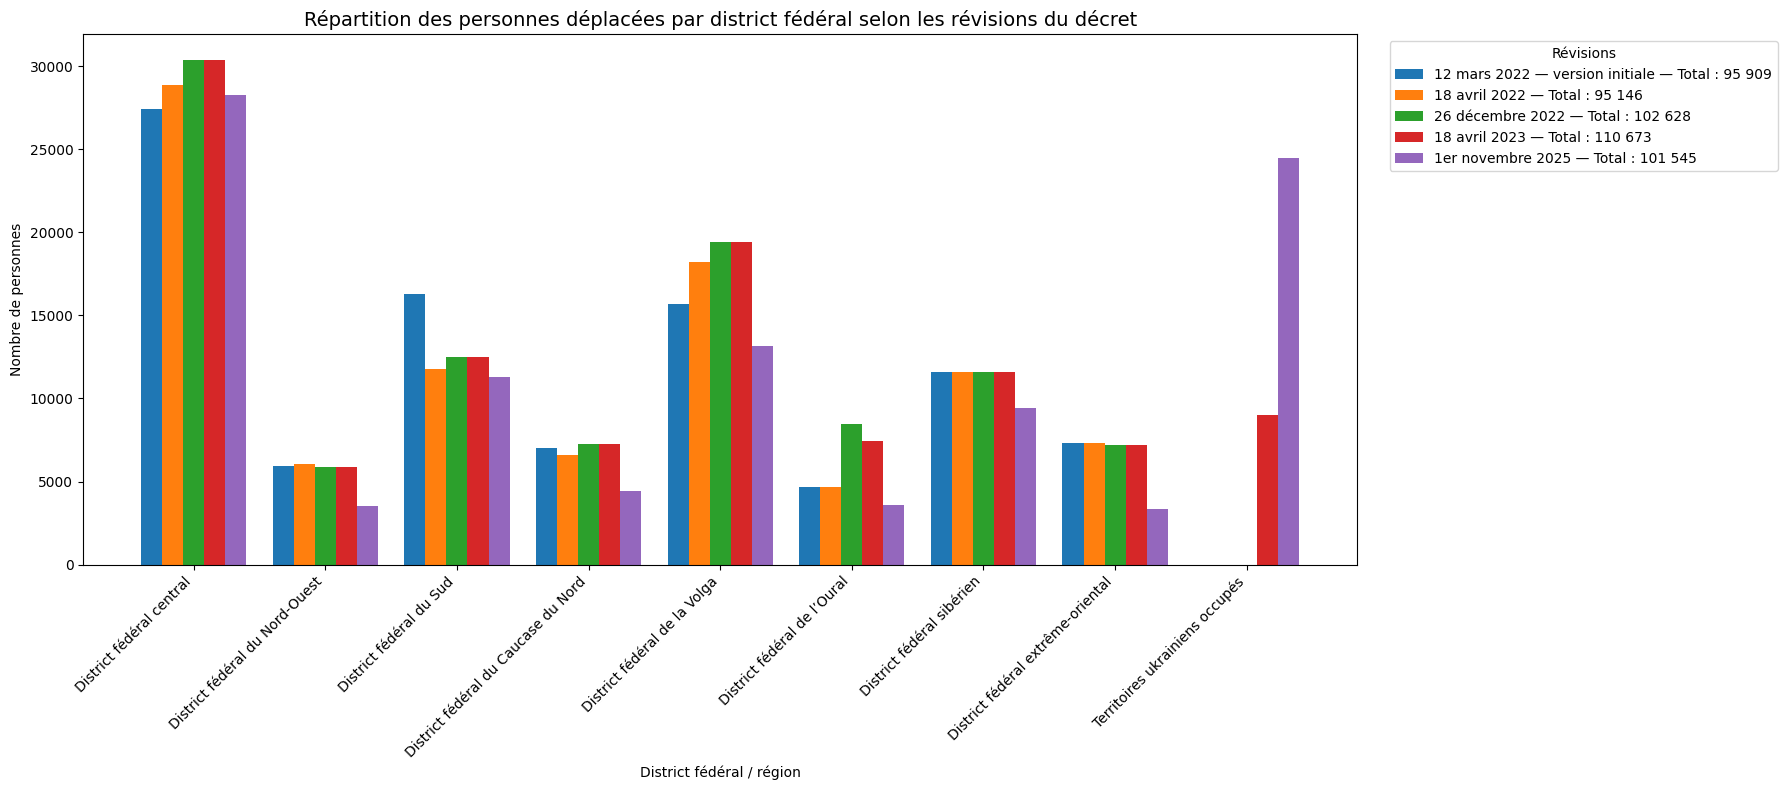

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Редакции в хронологическом порядке
revisions = [
    revision_2022_03_12,
    revision_2022_04_18,
    revision_2022_12_26,
    revision_2023_04_18,
    revision_2025_11_01
]

# Порядок округов / регионов на графике
district_order = [
    "District fédéral central",
    "District fédéral du Nord-Ouest",
    "District fédéral du Sud",
    "District fédéral du Caucase du Nord",
    "District fédéral de la Volga",
    "District fédéral de l’Oural",
    "District fédéral sibérien",
    "District fédéral extrême-oriental",
    "Territoires ukrainiens occupés"
]

# Автоматически создаём values для каждой редакции
for revision in revisions:
    revision["values"] = {
        district: revision["districts"][district]["total"]
        for district in revision["districts"]
    }

# Проверка total по каждой редакции
for revision in revisions:
    calculated_total = sum(revision["values"].values())
    print(
        revision["date"],
        "| Total calculé:",
        calculated_total,
        "| Total officiel:",
        revision["total"],
        "| Écart:",
        calculated_total - revision["total"]
    )

# Позиции по оси X
x = np.arange(len(district_order))

# Количество редакций и ширина столбиков
n_revisions = len(revisions)
bar_width = 0.8 / n_revisions

plt.figure(figsize=(18, 8))

# Строим столбики
for i, revision in enumerate(revisions):
    values = [
        revision["values"].get(district, 0)
        for district in district_order
    ]

    plt.bar(
        x + i * bar_width - (n_revisions - 1) * bar_width / 2,
        values,
        width=bar_width,
        label=f'{revision["date"]} — Total : {revision["total"]:,}'.replace(",", " ")
    )

# Название и оси
plt.title(
    "Répartition des personnes déplacées par district fédéral selon les révisions du décret",
    fontsize=14
)

plt.xlabel("District fédéral / région")
plt.ylabel("Nombre de personnes")

plt.xticks(
    x,
    district_order,
    rotation=45,
    ha="right"
)

# Легенда с датами и total
plt.legend(
    title="Révisions",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Сохраняем одним изображением
plt.savefig(
    "graphiques/histogramme_comparatif_revisions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()